<a href="https://colab.research.google.com/github/GUNAPILLCO/neural_profit/blob/main/notebooks/stage_03_target_definition/stage_03b_target_definition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **stage_03b_target_definition**


Vamos a reformular el Stage 03 partiendo exclusivamente del análisis empírico del mercado, y que el target sea una consecuencia de los datos, no un supuesto previo. El objetivo es que el MNQ nos “revele” cuál es una meta económicamente lógica, frecuente y operable.

## **Configuración del Entorno**


### 0.1. Acceso a Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')
drive_path = "/content/drive/MyDrive/neural_profit"

Mounted at /content/drive


### 0.2. Importación de librerías


In [3]:
import sys
import re
#Instalación de librería pandas_market_calendars
#!{sys.executable} -m pip install -q pandas_market_calendars
#print("Librería instalada: pandas_market_calendars")


from functools import reduce
# Utilidades generales
from datetime import datetime, timedelta
import os
import glob
import requests
import warnings
warnings.filterwarnings('ignore')

# Manejo y procesamiento de datos
#import ta
import pandas as pd
import numpy as np
from tabulate import tabulate
import matplotlib.pyplot as plt
# Calendario de mercados
#import pandas_market_calendars as mcal

#from ta.momentum import StochasticOscillator, ROCIndicator
#from ta.volatility import BollingerBands, AverageTrueRange

from scipy.stats import spearmanr
from __future__ import annotations  # permite type hints modernos (Python < 3.11)
import json                         # para guardar el summary como JSON
import os                           # para leer variables de entorno
from pathlib import Path            # manejo robusto de rutas
import pandas as pd

### 0.3. Definición de rutas

In [4]:
DRIVE_DIR =   Path(os.environ.get("DRIVE_DIR", "/content/drive/MyDrive/neural_profit/"))

In [5]:
# ---------------------------------------------------------------------
# Configuración de rutas (DVC-friendly)
# ---------------------------------------------------------------------
# Estas rutas son RELATIVAS al repositorio.
# DVC necesita paths locales y determinísticos.
# Si mañana quiere apuntar a Drive, se hace vía DVC remote o symlink,
# NO cambiando la lógica del stage.

# PARA EL DVC:
IN_PARQUET = Path(os.environ.get("IN_PARQUET", "data/processed/mnq_intraday.parquet"))
OUT_PARQUET = Path(os.environ.get("OUT_PARQUET", "data/processed/mnq_intraday_labeled.parquet"))
OUT_SUMMARY = Path(os.environ.get("OUT_SUMMARY", "reports/target_definitio_summary.json"))

In [6]:
# PARA EL NOTEBOOK:
IN_PARQUET = DRIVE_DIR / IN_PARQUET
OUT_PARQUET = DRIVE_DIR / OUT_PARQUET
OUT_SUMMARY = DRIVE_DIR / OUT_SUMMARY

### 0.4. Carga de dataset `intraday_mnq`


In [7]:
def load_mnq_parquet():
    os.path.exists(IN_PARQUET)
    print("Archivo encontrado en disco. Cargando dataset local...")
    mnq_parquet = pd.read_parquet(IN_PARQUET)
    return mnq_parquet

In [8]:
def add_column_date(df):
    # Asegurar que el índice esté en formato datetime
    df.index = pd.to_datetime(df.index)

    # Crear una nueva columna 'date' con la fecha extraída del índice
    df['date'] = df.index.date

    # Reordenar columnas: 'date', 'time_str', y luego el resto
    cols = ['date'] + [col for col in df.columns if col not in ['date']]

    df = df[cols]

    return df

In [9]:
def info_dataset(df):
  print("Información del dataset:\n")

  # Contar valores únicos en la columna 'date'
  num_dias = df['date'].nunique()
  print(f"\tCantidad de días: {num_dias}")

  # Filtrar valores válidos
  validos_por_dia = df.dropna(subset=['close']).groupby('date').size()

  # Calcular el promedio
  promedio_por_fecha = validos_por_dia.mean()
  print(f"\tRegistros por día: {int(promedio_por_fecha)}")

  primer_hora = df.index[0].strftime('%H:%M')
  ultima_hora = df.index[-1].strftime('%H:%M')
  zona_horaria = df.index[0].tzinfo


  print(f"\tHora diaria de inicio {primer_hora}")
  print(f"\tHora diaria de final {ultima_hora}")
  print(f"\tZona horaria: {zona_horaria}")

In [10]:
mnq_intraday = load_mnq_parquet()
mnq_intraday = add_column_date(mnq_intraday)
mnq_intraday.head()

Archivo encontrado en disco. Cargando dataset local...


,date,open,high,low,close,volume
datetime,,,,,,
2019-12-23 06:30:00-05:00,2019-12-23,8727.75,8728.00,8727.75,8727.75,7
2019-12-23 06:31:00-05:00,2019-12-23,8727.50,8727.75,8726.50,8726.50,89
2019-12-23 06:32:00-05:00,2019-12-23,8726.50,8726.50,8725.25,8725.25,34
2019-12-23 06:33:00-05:00,2019-12-23,8725.50,8726.25,8724.75,8726.00,53
2019-12-23 06:34:00-05:00,2019-12-23,8726.00,8726.00,8726.00,8726.00,3


In [11]:
info_dataset(mnq_intraday)

Información del dataset:

	Cantidad de días: 1303
	Registros por día: 571
	Hora diaria de inicio 06:30
	Hora diaria de final 16:00
	Zona horaria: America/New_York


## **1. Definición empírica del objetivo de predicción**

### **1.1. Marco teórico**


En problemas de predicción financiera intradía, la definición del target es una de las decisiones metodológicas más críticas, ya que condiciona simultáneamente la viabilidad estadística del modelo y su utilidad económica real.

En muchos enfoques tradicionales, los objetivos de predicción se definen exógenamente, fijando umbrales de retorno o movimiento en puntos (por ejemplo, ±25 o ±62.5 puntos) basados en criterios heurísticos, convenciones de mercado o metas deseadas de rentabilidad. Sin embargo, este enfoque presenta limitaciones estructurales:

1. Desacople con la dinámica real del mercado

    Umbrales arbitrarios pueden corresponder a eventos poco frecuentes o concentrados en ventanas horarias específicas, generando datasets altamente desbalanceados y modelos con baja capacidad de generalización.

2. Riesgo de optimización ilusoria

    Un modelo puede mostrar métricas estadísticas aceptables sobre un target mal definido, pero resultar económicamente inviable al ser aplicado en condiciones reales de trading.

3. Violación implícita de eficiencia intradía

    En horizontes cortos, la distribución de movimientos de precio está fuertemente condicionada por microestructura, volatilidad intradía y régimen horario, lo que invalida supuestos homogéneos sobre la magnitud de los retornos futuros.

### **1.2. Enfoque empírico orientado al mercado**

Frente a estas limitaciones, se adopta un enfoque empírico de definición del objetivo, en el cual el target de predicción emerge directamente de las distribuciones observadas de los movimientos futuros del precio.

Formalmente, para cada instante 𝑡 y horizonte ℎ, se define el movimiento futuro en puntos como:

$$
    \Delta \text{puntos}_{t,h} \approx r_{t,h} \times close_t
$$

El análisis de la distribución empírica de Δ𝑝𝑡𝑠_{𝑡,ℎ} permite:

- Identificar magnitudes de movimiento **frecuentes y recurrentes.**
- Distinguir metas **económicamente realistas** de eventos extremos.
- Evaluar la relación entre **frecuencia, magnitud y horizonte temporal**.
- Incorporar de manera natural la **asimetría** y **heterocedasticidad intradía** del mercado.

### **1.3. Principio de coherencia estadístico–económica**

El criterio central que guía este enfoque es el de **coherencia estadístico–económica**:

Un objetivo de predicción es válido si y solo si representa un movimiento que:
  - ocurre con frecuencia suficiente en los datos históricos, y
  - es económicamente significativo en términos de PnL neto.

Bajo este principio, los umbrales de predicción no se fijan a priori, sino que se derivan de estadísticas robustas (medianas, percentiles, persistencia horaria), garantizando que el modelo aprenda patrones **accionables** y no únicamente regularidades matemáticas.

### **1.4. Implicancia para el diseño del modelo**

Este marco teórico desplaza el foco desde la pregunta:

    “¿Puede el modelo predecir este objetivo?”

hacia una pregunta metodológicamente más correcta:

    “¿Qué objetivo tiene sentido predecir dadas las propiedades empíricas del mercado?”

Solo una vez respondida esta última, resulta legítimo avanzar hacia la definición de etiquetas, selección de métricas y entrenamiento de modelos.

## **2. Análisis empírico del movimiento intradía en puntos**

Luego de establecer el marco teórico, el análisis comienza directamente desde los datos históricos, sin imponer a priori ningún objetivo de predicción, umbral económico ni criterio direccional.

El propósito de esta etapa es caracterizar empíricamente el comportamiento real del mercado intradía y entender qué magnitudes de movimiento ocurren de forma natural en distintos horizontes temporales.

Este enfoque permite que la definición posterior del target sea una consecuencia del dataset, y no una decisión externa al mismo.

### **2.1. Dataset de partida**

El análisis se realiza sobre el dataset intradía del contrato MNQ, estructurado a nivel de minuto, con precios OHLCV y sin etiquetas de predicción predefinidas.
Cada fila representa un instante temporal independiente dentro de una jornada de trading, preservando la estructura intradía y evitando cruces entre sesiones.

In [12]:
mnq_intraday.head()

,date,open,high,low,close,volume
datetime,,,,,,
2019-12-23 06:30:00-05:00,2019-12-23,8727.75,8728.00,8727.75,8727.75,7
2019-12-23 06:31:00-05:00,2019-12-23,8727.50,8727.75,8726.50,8726.50,89
2019-12-23 06:32:00-05:00,2019-12-23,8726.50,8726.50,8725.25,8725.25,34
2019-12-23 06:33:00-05:00,2019-12-23,8725.50,8726.25,8724.75,8726.00,53
2019-12-23 06:34:00-05:00,2019-12-23,8726.00,8726.00,8726.00,8726.00,3


### **2.2 Definición del movimiento futuro en puntos**

Para cada instante 𝑡 y horizonte temporal ℎ (expresado en minutos), se define el movimiento futuro del precio en puntos como:

  $$
    \Delta \text{pts}_{t,h} =  \text{close}_{t+h}-\text{close}_{t}
  $$
  
Esta definición permite medir, en unidades directamente económicas, el desplazamiento del precio observado a partir de cada minuto intradía.


### **2.3 Objetivo del análisis empírico**

A partir de la variable Δ𝑝𝑡𝑠_{𝑡,ℎ}, el análisis empírico busca responder las siguientes preguntas fundamentales:

- ¿Cuál es la magnitud típica de los movimientos intradía para distintos horizontes?
- ¿Qué tan frecuentes son los movimientos de distinta amplitud?
- ¿Cómo se distribuyen los movimientos positivos y negativos?
- ¿Qué valores representan el comportamiento central del mercado y cuáles corresponden a eventos de cola?
- ¿Existen horarios intradía en los que los movimientos presentan mayor magnitud, frecuencia o persistencia?
- ¿Es posible identificar ventanas temporales más favorables para la observación o ejecución de decisiones operativas?

Estas preguntas se abordan exclusivamente mediante estadística descriptiva y análisis exploratorio de datos, sin asumir aún criterios operativos, reglas de trading ni umbrales económicos predefinidos.

### **2.4 Estadísticos descriptivos considerados**

Sobre la distribución de Δ𝑝𝑡𝑠_{𝑡,ℎ} se analizan estadísticos descriptivos orientados a caracterizar tanto la magnitud típica de los movimientos intradía como su comportamiento temporal y operativo.

En primer lugar, se consideran estadísticos globales sobre la distribución completa:

- Media y mediana
- Percentiles `p50`, `p60`, `p70`,  `p80`, `p90`
- Distribución del valor absoluto ∣Δ𝑝𝑡𝑠_{𝑡,ℎ}∣
- Asimetría entre movimientos alcistas y bajistas

Dado el carácter heterocedástico del mercado intradía, el análisis prioriza estadísticas robustas, menos sensibles a valores extremos, con especial énfasis en la mediana y los percentiles.

Adicionalmente, con el fin de incorporar explícitamente la dimensión temporal intradía, se analizan estadísticos condicionados por horario (minute-of-day):

- Mediana y percentiles de ∣Δ𝑝𝑡𝑠_{𝑡,ℎ}∣ por minuto del día.
- Probabilidad de observar movimientos cuya magnitud supere distintos umbrales de puntos, tanto de forma global como condicionada por horario.
- Identificación de ventanas temporales con mayor frecuencia de movimientos significativos.

Finalmente, se incorporan medidas orientadas a evaluar la persistencia y estabilidad del comportamiento intradía:

- Persistencia direccional de los movimientos, analizada mediante rachas de signo y/o autocorrelación de corto plazo.
- Estabilidad de los estadísticos anteriores entre distintas jornadas, con el objetivo de descartar comportamientos concentrados en períodos aislados.

Este conjunto de estadísticos permite describir el mercado desde una perspectiva descriptiva y empírica, proporcionando la base cuantitativa necesaria para definir, en secciones posteriores, objetivos de predicción coherentes tanto desde el punto de vista estadístico como económico.

### **2.5 Rol de este análisis en la notebook**

Este apartado cumple un rol fundacional dentro de la notebook:

- No define aún targets ni labels.
- No evalúa modelos.
- No impone objetivos económicos.

Su función es **describir el mercado tal como es**, proporcionando la base empírica necesaria para que, en secciones posteriores, la definición del objetivo de predicción sea natural, defendible y coherente con los datos.

## **3. Cálculo de Δpts y análisis descriptivo (global + por horario)**

### **3.1 Construcción de Δpts por horizonte (sin cruzar días)**

In [14]:
HORIZONS = [30, 60, 90, 120]

def add_future_delta_pts_by_day(
    df: pd.DataFrame,
    close_col: str = "close",
    date_col: str = "date",
    horizons=(60, 90),
) -> pd.DataFrame:
    out = df.copy()
    g = out.groupby(date_col, sort=False)

    for h in horizons:
        fut_close = g[close_col].shift(-h)                 # close_{t+h} dentro del mismo día
        out[f"delta_pts_{h}"] = fut_close - out[close_col] # Δpts_{t,h}
        out[f"abs_delta_pts_{h}"] = out[f"delta_pts_{h}"].abs()
        out[f"sign_delta_{h}"] = np.sign(out[f"delta_pts_{h}"]).astype("float")

    return out


In [20]:
df_delta = add_future_delta_pts_by_day(mnq_intraday, horizons=HORIZONS)
# df_delta[[f"delta_pts_{h}" for h in HORIZONS]].head(10)

,date,open,high,low,close,volume,delta_pts_30,abs_delta_pts_30,sign_delta_30,delta_pts_60,abs_delta_pts_60,sign_delta_60,delta_pts_90,abs_delta_pts_90,sign_delta_90,delta_pts_120,abs_delta_pts_120,sign_delta_120,minute_of_day
datetime,,,,,,,,,,,,,,,,,,,
2019-12-23 06:30:00-05:00,2019-12-23,8727.75,8728.00,8727.75,8727.75,7,0.25,0.25,1.0,9.00,9.00,1.0,6.00,6.00,1.0,9.25,9.25,1.0,390
2019-12-23 06:31:00-05:00,2019-12-23,8727.50,8727.75,8726.50,8726.50,89,0.50,0.50,1.0,9.25,9.25,1.0,7.50,7.50,1.0,10.00,10.00,1.0,391
2019-12-23 06:32:00-05:00,2019-12-23,8726.50,8726.50,8725.25,8725.25,34,2.75,2.75,1.0,9.75,9.75,1.0,8.00,8.00,1.0,10.75,10.75,1.0,392
2019-12-23 06:33:00-05:00,2019-12-23,8725.50,8726.25,8724.75,8726.00,53,2.25,2.25,1.0,8.50,8.50,1.0,8.00,8.00,1.0,10.75,10.75,1.0,393
2019-12-23 06:34:00-05:00,2019-12-23,8726.00,8726.00,8726.00,8726.00,3,2.75,2.75,1.0,8.00,8.00,1.0,7.75,7.75,1.0,11.75,11.75,1.0,394
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-13 15:56:00-04:00,2025-06-13,21624.50,21635.00,21613.50,21617.50,3251,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,956
2025-06-13 15:57:00-04:00,2025-06-13,21616.50,21635.25,21615.75,21623.75,2201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,957
2025-06-13 15:58:00-04:00,2025-06-13,21623.25,21632.75,21616.50,21621.75,1859,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,958


### **3.2 Resumen global por horizonte (mediana, percentiles, asimetría)**

#### **3.2.1. Código**

In [21]:
import pandas as pd

def global_summary_delta_pts(df: pd.DataFrame, horizons=(60, 90)) -> pd.DataFrame:
    """
    Calcula un resumen descriptivo GLOBAL (sin segmentar por horario) de los deltas en puntos
    para una lista de horizontes.

    Requiere que existan en df las columnas:
      - delta_pts_{h}      : close_{t+h} - close_t
      - abs_delta_pts_{h}  : |delta_pts_{h}|

    Devuelve un DataFrame indexado por horizonte (horizon_min) con:
      - tamaño muestral (n)
      - estadísticos centrales (media, mediana)
      - percentiles de magnitud (p50..p90 de |Δ|)
      - proporciones de signo (pos/neg/zero)
    """
    rows = []  # aquí acumulamos un diccionario por cada horizonte

    # Itera por cada horizonte solicitado (ej: 60, 90)
    for h in horizons:
        # Serie con Δpts_{t,h}; se eliminan NaN (típicamente los últimos h minutos de cada día)
        s = df[f"delta_pts_{h}"].dropna()

        # Serie con |Δpts_{t,h}|; también se eliminan NaN
        a = df[f"abs_delta_pts_{h}"].dropna()

        # Construimos un resumen en formato dict para este horizonte h
        rows.append({
            # Horizonte (en minutos) para usar como identificador
            "horizon_min": h,

            # Cantidad de observaciones válidas (sin NaN) para este horizonte
            "n": int(s.shape[0]),

            # Promedio de Δpts (puede ser cercano a 0 si no hay sesgo direccional)
            "mean_delta": float(s.mean()),

            # Mediana de Δpts (más robusta que la media ante outliers)
            "median_delta": float(s.median()),

            # Percentiles de la magnitud |Δ|: describen “tamaño típico” del movimiento
            "p50_abs": float(a.quantile(0.50)),  # mediana de |Δ|
            "p60_abs": float(a.quantile(0.60)),
            "p70_abs": float(a.quantile(0.70)),
            "p80_abs": float(a.quantile(0.80)),
            "p90_abs": float(a.quantile(0.90)),  # cola: movimientos grandes pero menos frecuentes

            # Proporciones de signo en Δpts: balance long/short (sin umbral)
            "pos_ratio": float((s > 0).mean()),   # % de veces Δpts > 0
            "neg_ratio": float((s < 0).mean()),   # % de veces Δpts < 0
            "zero_ratio": float((s == 0).mean()), # % de veces Δpts = 0 (poco común)
        })

    # Convierte la lista de dicts a DataFrame y usa el horizonte como índice
    return pd.DataFrame(rows).set_index("horizon_min")


#### **3.2.2. Interpretración de métricas**

In [22]:
global_stats = global_summary_delta_pts(df_delta, horizons=HORIZONS)
global_stats

,n,mean_delta,median_delta,p50_abs,p60_abs,p70_abs,p80_abs,p90_abs,pos_ratio,neg_ratio,zero_ratio
horizon_min,,,,,,,,,,,
30,704923,0.225146,1.50,18.00,23.75,31.00,42.00,62.50,0.521875,0.474099,0.004026
60,665833,0.481132,2.75,26.75,35.00,46.00,61.75,90.50,0.528272,0.468883,0.002845
90,626743,0.826449,3.50,34.25,44.75,58.50,79.00,113.75,0.530584,0.467144,0.002272
120,587653,1.089829,4.75,41.50,54.25,70.75,94.50,134.50,0.533766,0.464412,0.001823


---

**`n`**: Cantidad de observaciones válidas por horizonte

- Disminuye al aumentar el horizonte (30 → 120).
- Es esperable: los últimos h minutos de cada día no tienen Δpts_{t,h}.
- Sigue siendo muy grande (≈ 600–700k), por lo que los estadísticos son muy estables.

---

**`mean_delta`**: Media del movimiento futuro en puntos.

- Es ligeramente positiva y crece con el horizonte.
- Interpretación:
  - No es una señal operativa directa.
  - Refleja drift estructural + efecto horario (aperturas fuertes).
- No debe usarse para definir target, porque:
  - Está influida por colas.
  - No representa el “movimiento típico”.

Conclusión: informativa, pero no accionable.

---

**`median_delta`**: Mediana del movimiento futuro en puntos (con signo).

- Crece de forma muy ordenada:
  - 30 → 1.50
  - 60 → 2.75
  - 90 → 3.50
  - 120 → 4.75
      
- Interpretación:
    - El mercado tiene un ligero sesgo positivo intradía.
    - El movimiento “central” con signo es pequeño.

Conclusión: confirma sesgo, pero el tamaño económico está en |Δ|, no aquí.

---

**`p50_abs`**: mediana de |Δ|

Esta es una **métrica clave**.

- Representa el movimiento típico absoluto.
- Resultados:
  - 30 min → 18 pts
  - 60 min → 26.75 pts
  - 90 min → 34.25 pts
  - 120 min → 41.50 pts

Interpretación:
- En 60 min, la mitad de las veces el mercado se mueve ≈ 27 puntos o más.
- Esto ya cuestiona cualquier target base menor a ese valor.

---

**`p60_abs` – `p70_abs`**: Zona de targets **“realistas”**.

Ejemplo 60 min:
- P60 → 35 pts
- P70 → 46 pts

Interpretación:
- Movimientos que:
  - Ocurren con frecuencia razonable.
  - Tienen impacto económico claro.
- Son los **mejores candidatos a target base**.

---

**`p80_abs`**:

Zona de **targets exigentes** pero recurrentes.
- 60 min → 61.75 pts
- 90 min → 79.00 pts

Interpretación:
- No son eventos raros.
- Ya requieren buen timing / buen horario.

---

**`p90_abs`**

Eventos de cola.
- 60 min → 90.5 pts
- 120 min → 134.5 pts

Interpretación:
- Ocurren ~10% del tiempo.
- No deben usarse como objetivo principal.

Sirven para:
  - Take-profit extendido.
  - Análisis de riesgo/volatilidad.

---

**`pos_ratio` / `neg_ratio`**:

Proporción de movimientos positivos y negativos.
- Muy estables:
  - ~52–53% positivos
  - ~46–47% negativos

Interpretación:
  - No hay sesgo direccional fuerte.
  - El problema es de magnitud, no de dirección.

Conclusión: justifica enfoque long/short simétrico.

---

**`zero_ratio`**

Movimientos exactamente nulos.
- < 0.5% en todos los horizontes.
- Irrelevante operativamente.

#### **3.2.3. Conclusiones de resultados**

El análisis descriptivo del movimiento futuro en puntos para distintos horizontes temporales permite extraer conclusiones cuantitativas claras respecto a qué escalas temporales y qué órdenes de magnitud en puntos resultan más adecuados para la definición de un objetivo de predicción, partiendo exclusivamente del comportamiento empírico del mercado.

- En primer lugar, los resultados muestran que la magnitud típica de los movimientos intradía crece de forma sistemática con el horizonte temporal. Para horizontes cortos, como 30 minutos, la mediana del movimiento absoluto se sitúa en torno a los 18 puntos, mientras que para horizontes de 60, 90 y 120 minutos esta magnitud aumenta progresivamente hasta aproximadamente 27, 34 y 42 puntos respectivamente. Esta relación confirma que el horizonte temporal es un determinante estructural del tamaño del movimiento esperado y descarta la conveniencia de utilizar un único criterio de puntos independiente del horizonte.

- En el horizonte de 30 minutos, los movimientos observados se concentran mayoritariamente en rangos relativamente acotados, con valores típicos que rara vez superan los 30 puntos salvo en eventos de cola. Esto sugiere que, si bien existen oportunidades económicamente relevantes en esta escala temporal, el margen en puntos es más reducido y el comportamiento resulta más sensible al ruido intradía y al horario específico. En consecuencia, este horizonte aparece como más exigente desde el punto de vista predictivo y menos robusto para la definición de un objetivo general.

- Para el horizonte de 60 minutos, se observa un salto significativo en la magnitud de los movimientos. La mediana del valor absoluto supera los 25 puntos y los percentiles intermedios muestran desplazamientos frecuentes del orden de varias decenas de puntos. Esta escala temporal combina un tamaño de movimiento claramente relevante desde el punto de vista económico con una alta cantidad de observaciones válidas, lo que la convierte en un horizonte particularmente adecuado para fijar un objetivo de predicción basado en puntos.

- El horizonte de 90 minutos profundiza esta dinámica, mostrando movimientos típicos aún mayores, con una mediana del movimiento absoluto superior a los 30 puntos y una mayor presencia de desplazamientos amplios. Aunque la frecuencia de oportunidades disminuye respecto a 60 minutos, la magnitud en puntos aumenta de forma consistente, reflejando un comportamiento más tendencial y menos dominado por fluctuaciones de corto plazo. Esto lo posiciona como un horizonte atractivo cuando el interés está puesto en capturar movimientos más extensos.

- En el caso del horizonte de 120 minutos, los movimientos en puntos alcanzan magnitudes elevadas de forma habitual, con valores centrales que superan los 40 puntos y colas significativamente más amplias. No obstante, esta escala temporal implica una menor cantidad de observaciones y una mayor exposición a cambios de régimen intradía, lo que introduce mayores desafíos operativos y de timing. Por este motivo, si bien los movimientos son grandes en términos de puntos, este horizonte resulta más adecuado como complemento o análisis exploratorio que como base inicial del objetivo de predicción.

- En conjunto, el análisis empírico sugiere que los horizontes de 60 y 90 minutos representan el mejor compromiso entre magnitud típica del movimiento en puntos, frecuencia de ocurrencia y estabilidad estadística. El horizonte de 30 minutos queda asociado a movimientos más acotados y dependientes del horario, mientras que el de 120 minutos presenta movimientos amplios pero con mayores exigencias contextuales.

Finalmente, dado que estos resultados corresponden a estadísticas globales agregadas sobre todo el intradía, se desprende como paso siguiente la necesidad de analizar cómo estas magnitudes en puntos se distribuyen a lo largo del día, con el fin de identificar ventanas temporales específicas en las que determinados horizontes alcanzan con mayor frecuencia movimientos relevantes y operativamente consistentes.


### **3.3 Análisis por horario (minute-of-day)**

#### **3.3.1. Marco metodológico del análisis intradía por horario**

Luego de caracterizar el comportamiento global del movimiento futuro en puntos para distintos horizontes temporales, resulta necesario incorporar explícitamente la dimensión temporal intradía. El mercado no presenta una dinámica homogénea a lo largo de la sesión, sino que alterna períodos de mayor y menor actividad, volatilidad y direccionalidad.


El objetivo de este subpunto es analizar cómo se distribuyen las magnitudes de movimiento en puntos a lo largo del día, identificando posibles diferencias estructurales entre horarios y evaluando si ciertos tramos intradía concentran movimientos más amplios, frecuentes o estables.

Este análisis permite responder preguntas clave como:

- ¿Existen horarios intradía en los que los movimientos en puntos son sistemáticamente mayores?
- ¿Cómo varía la magnitud típica del movimiento para un mismo horizonte según el momento del día?
- ¿Se concentran los movimientos de mayor amplitud en ventanas temporales específicas?
- ¿Qué tan estables son estos comportamientos entre distintas jornadas?

##### **1. Definición de la variable temporal intradía**

Para cada observación intradía se define la variable minute-of-day, que identifica el minuto específico dentro de la jornada de trading, calculado como:

- `minute_of_day = hora × 60 + minuto`

Esta variable permite agrupar observaciones de distintos días bajo un mismo instante intradía, preservando la estructura temporal sin mezclar sesiones.

##### **2. Estadísticos analizados por horario**

Para cada horizonte temporal considerado, y para cada valor de `minute_of_day`, se analizan los siguientes estadísticos sobre el movimiento futuro en puntos:

- Cantidad de observaciones válidas.
- Mediana del valor absoluto del movimiento.
- Percentiles superiores del valor absoluto (por ejemplo, percentiles intermedios y de cola).
- Proporción de movimientos positivos y negativos.
- Probabilidad de observar movimientos cuya magnitud supere distintos niveles de puntos.

Estos estadísticos permiten comparar horarios no solo por la magnitud típica de los movimientos, sino también por su frecuencia y estabilidad.

##### **3. Objetivo del análisis por horario**

El análisis por horario cumple un rol complementario al análisis global y persigue tres objetivos principales:

1. Identificar ventanas intradía en las que los movimientos en puntos presentan mayor magnitud típica para un horizonte dado.
2. Evaluar la heterogeneidad temporal del mercado, verificando si los estadísticos globales esconden comportamientos diferenciados según el momento del día.
3. Sentar las bases para una posterior selección de ventanas de observación o ejecución, sin introducir aún reglas operativas.

#### **3.3.2. Implementación (código)**

#### 3.3.2.1 Preparación de columnas (minute_of_day)

In [23]:
import numpy as np
import pandas as pd

# Asegurar orden temporal
df_delta = df_delta.sort_index()

# minute_of_day (si no existe)
if "minute_of_day" not in df_delta.columns:
    df_delta["minute_of_day"] = df_delta.index.hour * 60 + df_delta.index.minute

# date (si no existe)
if "date" not in df_delta.columns:
    df_delta["date"] = df_delta.index.date

#### 3.3.2.2 Estadísticos por minuto del día (mediana + percentiles + sesgo direccional)

In [24]:
def stats_by_minute_of_day(df: pd.DataFrame, h: int) -> pd.DataFrame:
    """
    Calcula estadísticos por minute_of_day para un horizonte h:
      - n
      - mediana y percentiles de |Δ|
      - media de |Δ|
      - proporción de Δ>0 y Δ<0
    Requiere columnas:
      - delta_pts_{h}
      - abs_delta_pts_{h}
      - minute_of_day
    """
    base = df[["minute_of_day", f"delta_pts_{h}", f"abs_delta_pts_{h}"]].dropna()

    g = base.groupby("minute_of_day", sort=True)

    out = g.agg(
        n=(f"abs_delta_pts_{h}", "size"),
        mean_abs=(f"abs_delta_pts_{h}", "mean"),
        median_abs=(f"abs_delta_pts_{h}", "median"),
    )

    # Percentiles (robustos y útiles para ver colas por horario)
    for q in [0.60, 0.70, 0.80, 0.90]:
        out[f"p{int(q*100)}_abs"] = g[f"abs_delta_pts_{h}"].quantile(q)

    # Sesgo direccional simple (sin umbrales)
    out["pos_ratio"] = g[f"delta_pts_{h}"].apply(lambda x: (x > 0).mean())
    out["neg_ratio"] = g[f"delta_pts_{h}"].apply(lambda x: (x < 0).mean())

    # Hora/minuto para lectura
    out["hour"] = (out.index // 60).astype(int)
    out["minute"] = (out.index % 60).astype(int)

    return out.sort_index()


In [25]:
H = 60  # o 90, 120...
by_time_60 = stats_by_minute_of_day(df_delta, h=60)
by_time_90 = stats_by_minute_of_day(df_delta, h=90)

by_time_60.head()

,n,mean_abs,median_abs,p60_abs,p70_abs,p80_abs,p90_abs,pos_ratio,neg_ratio,hour,minute
minute_of_day,,,,,,,,,,,
390,1303,21.268995,15.25,19.75,25.00,32.75,47.25,0.562548,0.432847,6,30
391,1303,21.009210,14.50,19.00,24.50,31.50,47.00,0.560246,0.434382,6,31
392,1303,20.908672,15.00,19.00,23.50,32.00,46.75,0.556408,0.438219,6,32
393,1303,20.868573,14.75,19.00,24.00,32.40,45.90,0.547966,0.445127,6,33
394,1303,20.677859,14.50,18.50,24.75,32.50,44.65,0.556408,0.439754,6,34


#### 3.3.2.3 Ranking de horarios (top 20 por magnitud típica y por cola)

In [27]:
def top_minutes(df_by_time: pd.DataFrame, col: str, top_n: int = 20) -> pd.DataFrame:
    """
    Devuelve top horarios según una métrica (ej: median_abs, p80_abs, p90_abs)
    """
    cols_show = ["hour", "minute", "n", "mean_abs", "median_abs", "p60_abs", "p70_abs", "p80_abs", "p90_abs", "pos_ratio", "neg_ratio"]
    return df_by_time.sort_values(col, ascending=False)[cols_show].head(top_n)



In [45]:
top_med_60 = top_minutes(by_time_60, col="median_abs", top_n=20)
top_p80_60 = top_minutes(by_time_60, col="p80_abs", top_n=20)
top_p90_60 = top_minutes(by_time_60, col="p90_abs", top_n=20)

print('\nH:60 - Ranking de horarios (top 20 por magnitud típica y por cola\n')
top_med_60


H:60 - Ranking de horarios (top 20 por magnitud típica y por cola



,hour,minute,n,mean_abs,median_abs,p60_abs,p70_abs,p80_abs,p90_abs,pos_ratio,neg_ratio
minute_of_day,,,,,,,,,,,
570,9,30,1303,68.725058,55.25,70.00,88.85,108.00,142.70,0.524942,0.474290
569,9,29,1303,68.757099,54.50,71.00,88.25,108.55,147.00,0.524942,0.474290
568,9,28,1303,68.199923,54.50,69.50,86.75,108.65,145.15,0.526477,0.473523
571,9,31,1303,67.619916,53.75,68.50,84.85,106.75,144.45,0.522640,0.475825
563,9,23,1303,67.285495,53.75,67.25,84.85,107.00,143.20,0.527245,0.471988
564,9,24,1303,67.152533,52.50,67.05,86.10,105.10,143.25,0.524175,0.475825
565,9,25,1303,67.585572,52.25,68.80,87.10,107.40,142.65,0.537222,0.462011
567,9,27,1303,67.637375,52.00,68.75,87.85,107.90,143.95,0.524175,0.475058
572,9,32,1303,66.047199,51.75,66.05,82.85,105.75,137.95,0.528780,0.469685


- La mayor magnitud típica se concentra claramente entre las 09:18 y 09:41, con un pico muy marcado alrededor de 09:25–09:32.
- En ese tramo horario:
  - La mediana del movimiento ronda 50–55 puntos.
  - Los movimientos “grandes” (cola):
    - P80 ≈ 105–110 puntos
    - P90 ≈ 135–145 puntos

- La consistencia es alta:
  - Todos los minutos tienen prácticamente el mismo n (≈1300 días), lo que indica que no es un efecto puntual, sino estructural.

- No hay sesgo direccional fuerte:
  - Proporción long/short cercana a 50/50.
  - El atractivo del horario está en la magnitud, no en la dirección.

- Este bloque horario representa una ventana intradía dominante:
  - Alta magnitud típica.
  - Colas amplias.
  - Estabilidad estadística.

**Lectura clave**

Para un horizonte de 60 minutos, el mercado muestra que las primeras decenas de minutos posteriores a la apertura concentran los movimientos más grandes del día, tanto típicos como extremos.

Cualquier definición posterior de objetivo de predicción para este horizonte debería necesariamente considerar este tramo horario.

In [46]:
top_med_90 = top_minutes(by_time_90, col="median_abs", top_n=20)
top_p80_90 = top_minutes(by_time_90, col="p80_abs", top_n=20)
top_p90_90 = top_minutes(by_time_90, col="p90_abs", top_n=20)

print('\nH:90 - Ranking de horarios (top 20 por magnitud típica y por cola\n')
top_med_90


H:90 - Ranking de horarios (top 20 por magnitud típica y por cola



,hour,minute,n,mean_abs,median_abs,p60_abs,p70_abs,p80_abs,p90_abs,pos_ratio,neg_ratio
minute_of_day,,,,,,,,,,,
562,9,22,1303,77.350729,63.00,79.00,96.25,121.00,163.65,0.529547,0.468150
560,9,20,1303,77.413661,62.75,79.80,96.45,122.30,163.40,0.537222,0.460476
561,9,21,1303,77.418841,62.50,78.75,97.75,120.75,164.40,0.533384,0.463546
569,9,29,1303,77.966232,62.25,78.25,98.60,123.90,168.15,0.524942,0.474290
559,9,19,1303,76.586723,62.00,78.30,95.60,121.75,159.15,0.538757,0.460476
570,9,30,1303,78.227360,62.00,78.00,99.85,124.50,166.70,0.521873,0.476592
564,9,24,1303,78.161358,62.00,79.00,97.60,122.35,164.50,0.527245,0.471988
571,9,31,1303,76.282617,61.75,76.50,94.45,122.40,162.45,0.524175,0.474290
558,9,18,1303,76.180545,61.75,77.25,96.10,118.75,159.60,0.538757,0.459708


- La mayor magnitud típica se concentra entre las 09:15 y 09:31, con un núcleo muy claro alrededor de 09:20–09:30.

-  En ese tramo horario:
    - La mediana del movimiento se sitúa de forma consistente alrededor de 60–63 puntos.
    - Los movimientos amplios son frecuentes:
      - P80 ≈ 120–125 puntos
      - P90 ≈ 160–170 puntos

- La estructura es extremadamente estable:
  - Todos los minutos muestran el mismo tamaño muestral (n ≈ 1300), lo que confirma que el patrón se repite día tras día.

- No se observa un sesgo direccional relevante:
  - Las proporciones de movimientos positivos y negativos permanecen cercanas al 50%.
  - El atractivo del horizonte de 90 minutos reside en la amplitud del movimiento, no en la dirección.

- En comparación con el horizonte de 60 minutos:
  - La ventana horaria es ligeramente más temprana.
  - La magnitud típica y las colas son claramente mayores.
  - La frecuencia de movimientos grandes disminuye, pero el tamaño compensa.

**Lectura clave**

Para un horizonte de 90 minutos, el mercado muestra que la franja inmediatamente posterior a la apertura concentra movimientos amplios y consistentes, con desplazamientos típicos del orden de varias decenas de puntos y colas significativamente más grandes que en 60 minutos.

Este horizonte resulta especialmente adecuado para capturar movimientos intradía extensos, siempre que se considere explícitamente el factor horario.


#### 3.3.2.4 Probabilidad de exceder niveles de puntos por horario (frecuencia)

In [30]:
LEVELS_PTS = [10, 20, 30, 40, 50, 60, 80, 100]

def prob_exceed_levels_by_time(df: pd.DataFrame, h: int, levels_pts) -> pd.DataFrame:
    """
    Para cada minute_of_day calcula:
      - n
      - P(|Δ| >= k) para varios niveles k (en puntos)
    """
    base = df[["minute_of_day", f"abs_delta_pts_{h}"]].dropna()
    g = base.groupby("minute_of_day")[f"abs_delta_pts_{h}"]

    out = pd.DataFrame(index=sorted(base["minute_of_day"].unique()))
    out["n"] = g.size()

    for k in levels_pts:
        out[f"P(|Δ|>={k})"] = g.apply(lambda x: (x >= k).mean())

    out["hour"] = (out.index // 60).astype(int)
    out["minute"] = (out.index % 60).astype(int)

    return out.sort_index()


In [31]:
p_by_time_60 = prob_exceed_levels_by_time(df_delta, h=60, levels_pts=LEVELS_PTS)
p_by_time_60.head()

,n,P(|Δ|>=10),P(|Δ|>=20),P(|Δ|>=30),P(|Δ|>=40),P(|Δ|>=50),P(|Δ|>=60),P(|Δ|>=80),P(|Δ|>=100),hour,minute
390,1303,0.652341,0.397544,0.235610,0.138143,0.087490,0.054490,0.027629,0.009210,6,30
391,1303,0.636992,0.385265,0.216424,0.135840,0.093630,0.062932,0.023791,0.009210,6,31
392,1303,0.647736,0.382962,0.220261,0.137375,0.092863,0.054490,0.026094,0.011512,6,32
393,1303,0.648503,0.382962,0.220261,0.132771,0.079816,0.054490,0.024559,0.009210,6,33
394,1303,0.646201,0.372218,0.231005,0.130468,0.082118,0.052187,0.022256,0.010744,6,34


In [32]:
p_by_time_90 = prob_exceed_levels_by_time(df_delta, h=90, levels_pts=LEVELS_PTS)
p_by_time_90.head()

,n,P(|Δ|>=10),P(|Δ|>=20),P(|Δ|>=30),P(|Δ|>=40),P(|Δ|>=50),P(|Δ|>=60),P(|Δ|>=80),P(|Δ|>=100),hour,minute
390,1303,0.712970,0.462011,0.297774,0.196470,0.130468,0.090560,0.039908,0.023024,6,30
391,1303,0.712203,0.469685,0.307751,0.197237,0.134305,0.089025,0.039908,0.019954,6,31
392,1303,0.708365,0.460476,0.306984,0.201074,0.132003,0.091328,0.036838,0.020721,6,32
393,1303,0.700691,0.464313,0.306216,0.201074,0.136608,0.082886,0.038373,0.020721,6,33
394,1303,0.693784,0.468918,0.313124,0.201074,0.135073,0.086723,0.036071,0.016117,6,34


##### Top horarios por frecuencia para un nivel específico:

In [52]:
K = 40  # Puntos
cols = ["hour", "minute", "n", f"P(|Δ|>={K})"]

In [53]:
top_freq_60 = p_by_time_60.sort_values(f"P(|Δ|>={K})", ascending=False)[cols].head(20)

print(f'Top horarios por frecuencia (top 20)')
print(f'H:60 - K: {K}pts. - Top horarios por frecuencia (top 20)\n')
top_freq_60

Top horarios por frecuencia (top 20)
H:60 - K: 40pts. - Top horarios por frecuencia (top 20)



,hour,minute,n,P(|Δ|>=40)
569,9,29,1303,0.618573
570,9,30,1303,0.616270
567,9,27,1303,0.610130
568,9,28,1303,0.607828
564,9,24,1303,0.607828
563,9,23,1303,0.604758
572,9,32,1303,0.603991
562,9,22,1303,0.603223
571,9,31,1303,0.602456
561,9,21,1303,0.601688


In [54]:
top_freq_90 = p_by_time_90.sort_values(f"P(|Δ|>={K})", ascending=False)[cols].head(20)

print(f'Top horarios por frecuencia (top 20)')
print(f'H:90 - K: {K}pts. - Top horarios por frecuencia (top 20)\n')
top_freq_90

Top horarios por frecuencia (top 20)
H:90 - K: 40pts. - Top horarios por frecuencia (top 20)



,hour,minute,n,P(|Δ|>=40)
576,9,36,1303,0.657713
575,9,35,1303,0.657713
563,9,23,1303,0.656946
568,9,28,1303,0.656946
567,9,27,1303,0.656178
569,9,29,1303,0.652341
570,9,30,1303,0.650806
556,9,16,1303,0.650806
554,9,14,1303,0.650038
565,9,25,1303,0.649271


#### 3.3.2.5 Visualización rápida (curva intradía)

In [42]:
import matplotlib.pyplot as plt

def plot_intraday_curve(df_by_time: pd.DataFrame, y_col: str, title: str):
    """
    Grafica una curva intradía usando hora:minuto en el eje X.
    df_by_time debe tener columnas: 'hour' y 'minute'.
    """

    # Construimos etiquetas hh:mm
    x_labels = df_by_time["hour"].astype(str).str.zfill(2) + ":" + \
               df_by_time["minute"].astype(str).str.zfill(2)

    y = df_by_time[y_col].values

    plt.figure(figsize=(14, 4))
    plt.plot(range(len(y)), y)

    # Reducimos cantidad de ticks para legibilidad (ej: uno cada 30 minutos)
    step = 30
    tick_pos = range(0, len(x_labels), step)
    tick_lab = x_labels.iloc[tick_pos]

    plt.xticks(tick_pos, tick_lab, rotation=45)
    plt.title(title)
    plt.xlabel("Hora del día")
    plt.ylabel(y_col)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

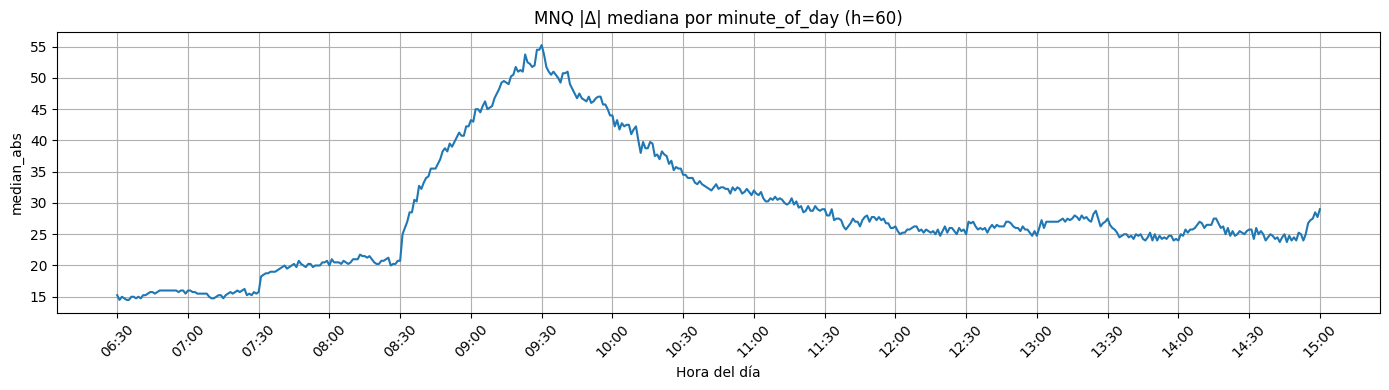

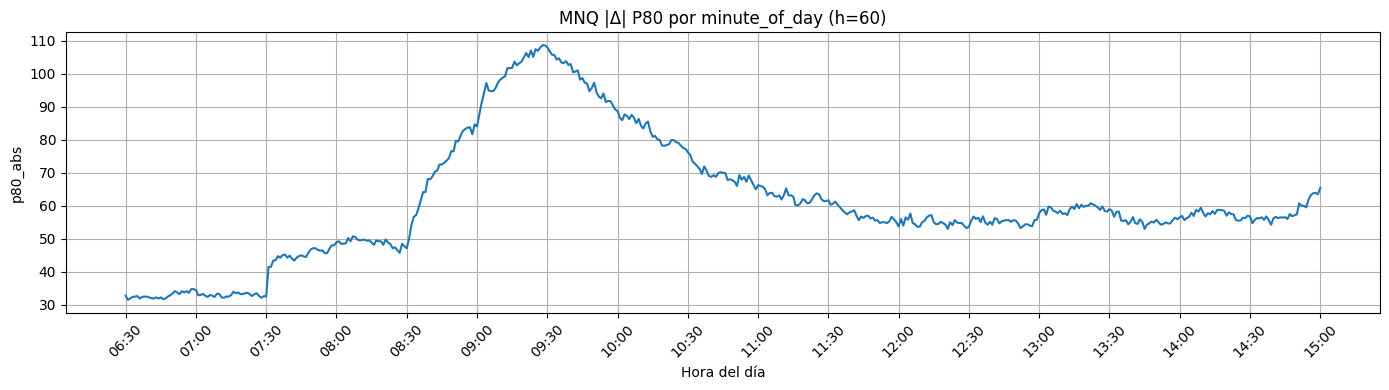

In [43]:
plot_intraday_curve(by_time_60, "median_abs", "MNQ |Δ| mediana por minute_of_day (h=60)")
plot_intraday_curve(by_time_60, "p80_abs", "MNQ |Δ| P80 por minute_of_day (h=60)")

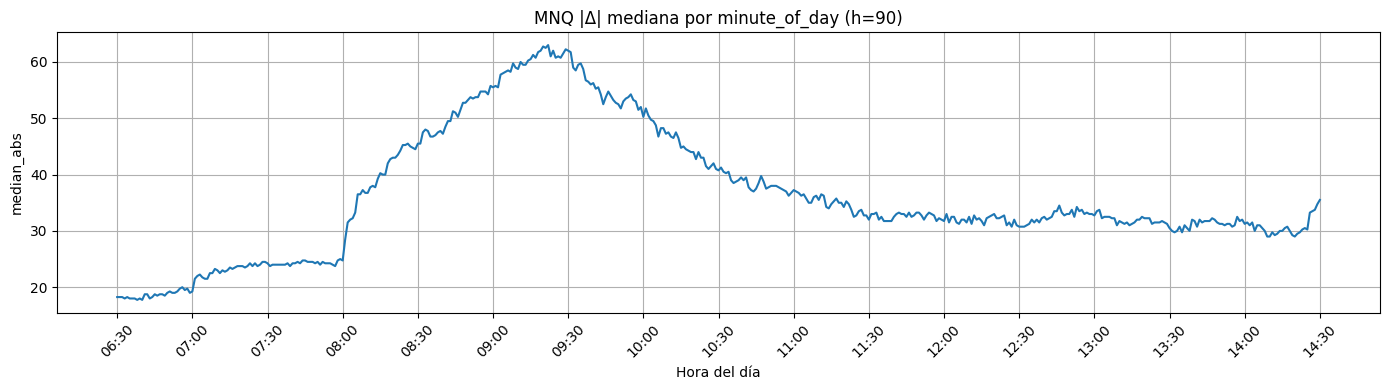

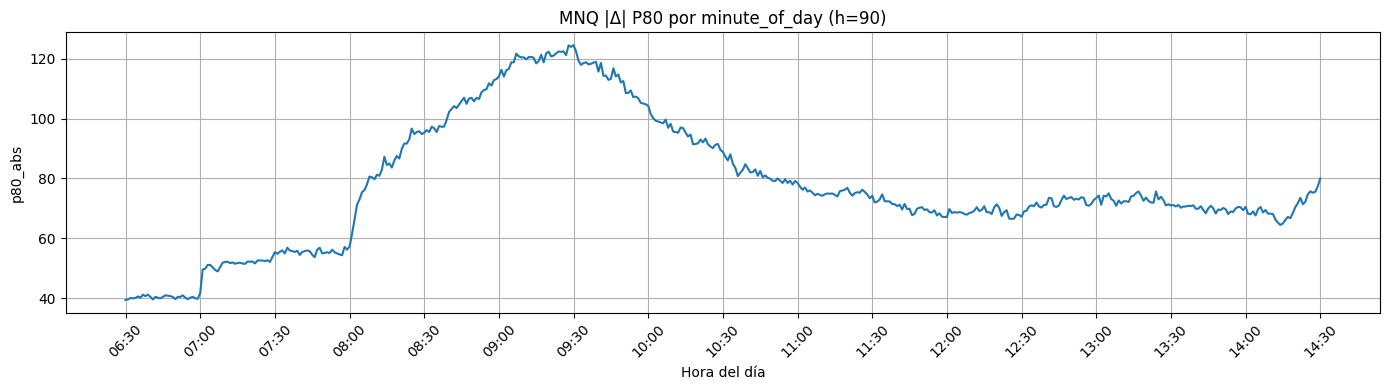

In [44]:
plot_intraday_curve(by_time_90, "median_abs", "MNQ |Δ| mediana por minute_of_day (h=90)")
plot_intraday_curve(by_time_90, "p80_abs", "MNQ |Δ| P80 por minute_of_day (h=90)")

## **4. Definición empírica del delta objetivo según perfiles de magnitud y frecuencia**

### **4.1. Marco conceptual**

Del punto `3.3.2.4 Probabilidad de exceder niveles de puntos por horario (frecuencia)` vamos a obtener `p_by_time_60` y `p_by_time_90`

En este punto se busca derivar empíricamente objetivos de movimiento en puntos, condicionados al horizonte temporal y al horario intradía, sin fijar umbrales a priori.

En particular, se analizan:

1. Resumen por nivel de puntos, mediante estadísticas agregadas (media, mediana y dispersión) de la probabilidad de exceder cada nivel en los horarios intradía más activos.

2. Delta base sugerido, definido como el mayor nivel de puntos que cumple un criterio mínimo de probabilidad y estabilidad temporal.

3. Ventanas horarias recomendadas, identificadas como rangos continuos de tiempo donde el criterio anterior se cumple de forma consistente.

El análisis se realiza evaluando **dos perfiles de exigencia**, con el objetivo de comparar distintos compromisos entre magnitud del movimiento y frecuencia de ocurrencia:

- **Perfil de alta magnitud (expansivo)**: probabilidad mínima del 30% y ventana continua de al menos 15 minutos, orientado a capturar movimientos grandes y estructurales, aceptando una menor frecuencia de ocurrencia.

- **Perfil de alta frecuencia (defensivo)**: probabilidad mínima del 50% y ventana continua de al menos 30 minutos, orientado a capturar movimientos más frecuentes y estables, a costa de una menor magnitud del movimiento.

Este enfoque permite contrastar distintos criterios operativos y evaluar cómo varía el objetivo de predicción según el nivel de exigencia adoptado, dejando la selección final del perfil para etapas posteriores del análisis.

### **4.2. Implementación**

In [73]:
import re
import numpy as np
import pandas as pd


# ---------------------------------------------------------------------
# Utilidades básicas
# ---------------------------------------------------------------------

def _ensure_minute_of_day(df: pd.DataFrame) -> pd.DataFrame:
    """
    Asegura que exista 'minute_of_day' (0..1439).
    Si no existe, lo calcula desde 'hour' y 'minute'.
    Devuelve una copia ordenada por minute_of_day.
    """
    out = df.copy()

    if "minute_of_day" not in out.columns:
        if "hour" in out.columns and "minute" in out.columns:
            out["minute_of_day"] = out["hour"].astype(int) * 60 + out["minute"].astype(int)
        else:
            raise ValueError("El DataFrame debe tener 'minute_of_day' o bien 'hour' y 'minute'.")

    # Normalizamos a int por robustez (algunos merges dejan float)
    out["minute_of_day"] = out["minute_of_day"].astype(int)

    # Si no están, construimos hour/minute solo para reporting
    if "hour" not in out.columns:
        out["hour"] = (out["minute_of_day"] // 60).astype(int)
    if "minute" not in out.columns:
        out["minute"] = (out["minute_of_day"] % 60).astype(int)

    return out.sort_values("minute_of_day")


def _prob_cols(df: pd.DataFrame, prefix: str = "P(|Δ|>=") -> list[str]:
    """
    Devuelve las columnas de probabilidad con prefijo 'P(|Δ|>=':
      P(|Δ|>=10), P(|Δ|>=20), ...
    """
    cols = [c for c in df.columns if c.startswith(prefix)]
    if not cols:
        raise ValueError(f"No encontré columnas de probabilidad con prefijo '{prefix}'.")
    return cols


def _level_from_col(col: str) -> float:
    """
    Extrae el nivel numérico k desde el nombre de columna.
    Soporta formatos típicos:
      - P(|Δ|>=50)
      - P(|Δ|>=62.5)
    """
    # Regex: captura lo que está después de ">=" y antes de ")"
    m = re.search(r">=\s*([0-9]+(?:\.[0-9]+)?)\)", col)
    if not m:
        raise ValueError(f"No pude parsear el nivel k desde la columna: {col}")
    return float(m.group(1))


def _fmt_hhmm(m: int) -> str:
    """Convierte minute_of_day a string HH:MM."""
    hh = int(m) // 60
    mm = int(m) % 60
    return f"{hh:02d}:{mm:02d}"


def _ordered_prob_cols(df: pd.DataFrame, prefix: str = "P(|Δ|>=") -> list[str]:
    """
    Devuelve las columnas P(|Δ|>=k) ordenadas por k ascendente.
    """
    cols = _prob_cols(df, prefix=prefix)
    cols_with_k = [(c, _level_from_col(c)) for c in cols]
    cols_with_k.sort(key=lambda x: x[1])
    return [c for c, _ in cols_with_k]


def _pick_rank_col(df: pd.DataFrame, rank_k: float | None, prefix: str = "P(|Δ|>=") -> str:
    """
    Elige la columna que se usará para rankear los 'top_minutes'.

    - Si rank_k es None: usa el k más alto disponible (comportamiento anterior).
    - Si rank_k está definido: intenta usar exactamente P(|Δ|>=rank_k).
      Si no existe exacto, usa el k más cercano (por arriba y por debajo) y elige el más cercano.
    """
    pcols_sorted = _ordered_prob_cols(df, prefix=prefix)
    ks = np.array([_level_from_col(c) for c in pcols_sorted], dtype=float)

    if rank_k is None:
        return pcols_sorted[-1]  # k máximo (más exigente)

    # Buscar el k más cercano disponible
    idx = int(np.argmin(np.abs(ks - float(rank_k))))
    return pcols_sorted[idx]


# ---------------------------------------------------------------------
# Paso 1: resumen por nivel de puntos (en top horarios)
# ---------------------------------------------------------------------

def summarize_levels(
    df_probs: pd.DataFrame,
    top_minutes: int = 60,
    metric_col: str | None = None,
    prefix: str = "P(|Δ|>=",
) -> pd.DataFrame:
    """
    PASO 1:
    Para cada nivel k, calcula estadísticas agregadas de P(|Δ|>=k)
    sobre los 'top_minutes' horarios seleccionados por 'metric_col'.

    Si metric_col es None, usa el nivel más alto disponible para rankear.

    Devuelve DataFrame indexado por k_pts con:
      mean_P, median_P, p25_P, p75_P, min_P, max_P, top_minutes_used, ranked_by
    """
    df = _ensure_minute_of_day(df_probs)
    pcols_sorted = _ordered_prob_cols(df, prefix=prefix)

    # Columna de ranking (por defecto k máximo)
    if metric_col is None:
        metric_col = pcols_sorted[-1]

    if metric_col not in df.columns:
        raise ValueError(f"metric_col='{metric_col}' no está en df. Use una columna tipo 'P(|Δ|>=k)'.")

    # Top N minutos según la métrica elegida
    top_n = min(int(top_minutes), int(df.shape[0]))
    top = df.nlargest(top_n, metric_col).copy()

    # Construimos resumen por nivel k sobre los top minutos
    rows = []
    for c in pcols_sorted:
        k = _level_from_col(c)
        rows.append({
            "k_pts": k,
            "mean_P": float(top[c].mean()),
            "median_P": float(top[c].median()),
            "p25_P": float(top[c].quantile(0.25)),
            "p75_P": float(top[c].quantile(0.75)),
            "min_P": float(top[c].min()),
            "max_P": float(top[c].max()),
            "top_minutes_used": int(top.shape[0]),
            "ranked_by": metric_col,
        })

    return pd.DataFrame(rows).set_index("k_pts")


# ---------------------------------------------------------------------
# Ventanas: continuidad con tolerancia a gaps + métricas por ventana
# ---------------------------------------------------------------------

def _windows_with_gaps(minutes: np.ndarray, min_len: int, max_gap: int = 0) -> list[tuple[int, int]]:
    """
    Detecta ventanas de minute_of_day "casi contiguas" permitiendo gaps pequeños.

    - min_len: longitud mínima de la ventana en minutos (conteo discreto sobre el rango start..end)
    - max_gap: máximo gap permitido entre puntos consecutivos sin romper ventana.
      Ej:
        max_gap=0 => contiguidad estricta (m == prev+1)
        max_gap=2 => permite saltos de hasta 2 minutos (m <= prev+1+2)

    Devuelve lista de (start, end) en minute_of_day, donde (end-start+1) >= min_len.
    """
    if minutes.size == 0:
        return []

    minutes = np.sort(minutes.astype(int))

    windows = []
    start = minutes[0]
    prev = minutes[0]

    for m in minutes[1:]:
        # Si el siguiente punto está "cerca" (dentro del gap tolerado), seguimos la ventana
        if m <= prev + 1 + int(max_gap):
            prev = m
        else:
            # Cerramos ventana si su rango cubre al menos min_len minutos
            if (prev - start + 1) >= int(min_len):
                windows.append((start, prev))
            start = m
            prev = m

    # Cerrar última ventana
    if (prev - start + 1) >= int(min_len):
        windows.append((start, prev))

    return windows


def _window_stats(df_top: pd.DataFrame, prob_col: str, start: int, end: int) -> dict:
    """
    Calcula métricas de la probabilidad dentro de una ventana [start, end] (minute_of_day),
    usando df_top (ya filtrado a top_minutes).

    Devuelve estadísticas útiles para justificar el resultado:
      - mean_P_in_window, median_P_in_window, min_P_in_window, p25/p75
      - n_minutes_in_window (minutos presentes en df_top dentro del rango)
    """
    mask = (df_top["minute_of_day"] >= int(start)) & (df_top["minute_of_day"] <= int(end))
    sub = df_top.loc[mask, prob_col].dropna()

    if sub.empty:
        return {
            "n_minutes_in_window": 0,
            "mean_P_in_window": np.nan,
            "median_P_in_window": np.nan,
            "min_P_in_window": np.nan,
            "p25_P_in_window": np.nan,
            "p75_P_in_window": np.nan,
        }

    return {
        "n_minutes_in_window": int(sub.shape[0]),
        "mean_P_in_window": float(sub.mean()),
        "median_P_in_window": float(sub.median()),
        "min_P_in_window": float(sub.min()),
        "p25_P_in_window": float(sub.quantile(0.25)),
        "p75_P_in_window": float(sub.quantile(0.75)),
    }


# ---------------------------------------------------------------------
# Paso 2: recomendación de delta base + ventanas (perfil paramétrico)
# ---------------------------------------------------------------------

def recommend_base_delta(
    df_probs: pd.DataFrame,
    p_min: float = 0.30,
    window_minutes: int = 15,
    top_minutes: int = 120,
    prefix: str = "P(|Δ|>=",
    rank_k: float | None = None,
    max_gap: int = 0,
    prefer_longest_window: bool = True,
) -> dict:
    """
    PASO 2 (mejorado):
    Encuentra el 'delta base' como el MAYOR nivel k (en puntos) tal que exista al menos una ventana
    donde P(|Δ|>=k) >= p_min, con estabilidad temporal:

      - ventana de rango >= window_minutes
      - continuidad con tolerancia de gaps: max_gap

    Además:
      - Permite elegir cómo rankear los top minutos: rank_k (en vez de usar siempre k máximo).
      - Devuelve métricas por ventana para justificar el resultado.

    Parámetros:
      p_min: probabilidad mínima aceptable.
      window_minutes: longitud mínima de la ventana (en minutos, sobre el rango start..end).
      top_minutes: cantidad de minutos intradía usados (los mejores según ranking).
      rank_k: nivel k usado para rankear top_minutes. Si None, usa el k máximo disponible.
      max_gap: tolerancia de gaps en continuidad (0 = estricto).
      prefer_longest_window:
        - True: elige la ventana más larga (si hay varias) para el k elegido.
        - False: elige la ventana con mayor 'min_P_in_window' (más estable).

    Devuelve dict con:
      - delta_base_pts
      - windows (lista detallada)
      - chosen_window (la ventana seleccionada)
      - level_table
      - ranking_info
    """
    df = _ensure_minute_of_day(df_probs)

    # Columnas ordenadas por k ascendente
    pcols_sorted = _ordered_prob_cols(df, prefix=prefix)

    # Elegimos la columna para rankear top_minutes (configurable)
    metric_col = _pick_rank_col(df, rank_k=rank_k, prefix=prefix)

    # Tomamos top_minutes según la métrica elegida
    top_n = min(int(top_minutes), int(df.shape[0]))
    df_top = df.nlargest(top_n, metric_col).copy()

    # Tabla resumen por nivel para inspección (sobre df_top)
    level_table = summarize_levels(
        df_top,
        top_minutes=top_n,
        metric_col=metric_col,
        prefix=prefix
    )

    chosen_k = None
    chosen_windows = []
    chosen_prob_col = None

    # Buscamos el mayor k que cumpla el criterio
    for prob_col in reversed(pcols_sorted):  # k grande -> chico
        k = _level_from_col(prob_col)

        # Minutos que cumplen P(|Δ|>=k) >= p_min dentro de df_top
        ok_minutes = df_top.loc[df_top[prob_col] >= float(p_min), "minute_of_day"].to_numpy()

        # Ventanas con continuidad y tolerancia a gaps
        windows = _windows_with_gaps(ok_minutes, min_len=int(window_minutes), max_gap=int(max_gap))

        if windows:
            chosen_k = k
            chosen_windows = windows
            chosen_prob_col = prob_col
            break

    # Si no hay solución, devolvemos diagnóstico útil
    if chosen_k is None:
        return {
            "delta_base_pts": None,
            "p_min": float(p_min),
            "window_minutes": int(window_minutes),
            "top_minutes_considered": int(top_n),
            "ranked_by": metric_col,
            "rank_k": rank_k,
            "max_gap": int(max_gap),
            "windows": [],
            "chosen_window": None,
            "level_table": level_table,
            "note": "No se encontró ningún nivel k que cumpla p_min y window_minutes con los parámetros dados."
        }

    # Formatear ventanas y calcular estadísticas por ventana
    windows_fmt = []
    for (s, e) in chosen_windows:
        stats = _window_stats(df_top, chosen_prob_col, s, e)
        windows_fmt.append({
            "start_minute_of_day": int(s),
            "end_minute_of_day": int(e),
            "start_hhmm": _fmt_hhmm(int(s)),
            "end_hhmm": _fmt_hhmm(int(e)),
            "length_min": int(e - s + 1),
            **stats,
        })

    # Elegimos una ventana "representativa" para reportar
    if prefer_longest_window:
        # Selecciona la ventana más larga; si empatan, la de mayor min_P_in_window
        chosen_window = sorted(
            windows_fmt,
            key=lambda d: (d["length_min"], d["min_P_in_window"]),
            reverse=True
        )[0]
    else:
        # Selecciona la ventana más estable (min_P más alto); si empatan, la más larga
        chosen_window = sorted(
            windows_fmt,
            key=lambda d: (d["min_P_in_window"], d["length_min"]),
            reverse=True
        )[0]

    return {
        "delta_base_pts": float(chosen_k),
        "p_min": float(p_min),
        "window_minutes": int(window_minutes),
        "top_minutes_considered": int(top_n),
        "ranked_by": metric_col,
        "rank_k": rank_k,
        "max_gap": int(max_gap),
        "windows": windows_fmt,
        "chosen_window": chosen_window,
        "level_table": level_table,
        "ranking_info": {
            "metric_col": metric_col,
            "rank_k_requested": rank_k,
            "top_minutes": int(top_n),
        }
    }


# ---------------------------------------------------------------------
# Helper opcional: ejecutar ambos perfiles (alta magnitud vs alta frecuencia)
# ---------------------------------------------------------------------

def run_profiles(
    df_probs: pd.DataFrame,
    top_minutes: int = 120,
    prefix: str = "P(|Δ|>=",
    rank_k: float | None = None,
    max_gap: int = 0,
) -> dict:
    """
    Ejecuta los dos perfiles definidos en la notebook:
      - Alta magnitud (expansivo): p_min=0.30, ventana>=15
      - Alta frecuencia (defensivo): p_min=0.50, ventana>=30

    Devuelve un dict con resultados para ambos perfiles.
    """
    res_high_mag = recommend_base_delta(
        df_probs=df_probs,
        p_min=0.30,
        window_minutes=15,
        top_minutes=top_minutes,
        prefix=prefix,
        rank_k=rank_k,
        max_gap=max_gap,
        prefer_longest_window=True
    )

    res_high_freq = recommend_base_delta(
        df_probs=df_probs,
        p_min=0.50,
        window_minutes=30,
        top_minutes=top_minutes,
        prefix=prefix,
        rank_k=rank_k,
        max_gap=max_gap,
        prefer_longest_window=True
    )

    return {
        "high_magnitude_expansive": res_high_mag,
        "high_frequency_defensive": res_high_freq
    }


In [ ]:
def recommend_base_delta(
    df_probs: pd.DataFrame,
    p_min: float = 0.30,
    window_minutes: int = 15,
    top_minutes: int = 120,
    prefix: str = "P(|Δ|>=",
    rank_k: float | None = None,
    max_gap: int = 0,
    prefer_longest_window: bool = True,
) -> dict:

In [101]:
def print_profile_result(res, horizon_label: str, profile_key: str, profile_name: str):
    r = res[profile_key]
    w = r["chosen_window"]

    print("=" * 60)
    print(f"{profile_name} — H = {horizon_label}")
    print("=" * 60)
    print(f"Delta base (pts):      {r['delta_base_pts']}")
    print(f"Probabilidad mínima:   {r['p_min']:.0%}")
    print(f"Ventana mínima (min):  {r['window_minutes']}")
    print(f"Top minutos usados:    {r['top_minutes_considered']}")
    print("-" * 60)
    if w is not None:
        print("Ventana horaria seleccionada:")
        print(f"  • Desde:             {w['start_hhmm']}")
        print(f"  • Hasta:             {w['end_hhmm']}")
        print(f"  • Duración (min):    {w['length_min']}")
        print(f"  • P mínima ventana:  {w['min_P_in_window']:.1%}")
        print(f"  • P mediana ventana: {w['median_P_in_window']:.1%}")
    else:
        print("No se encontró ventana que cumpla el criterio.")
    print("=" * 60)

def profile_to_df(res, horizon_label: str, profile_key: str, profile_name: str) -> pd.DataFrame:
    r = res[profile_key]
    w = r["chosen_window"]

    return pd.DataFrame([{
        "Perfil": profile_name,
        "Horizonte (min)": horizon_label,
        "Delta base (pts)": r["delta_base_pts"],
        "p_min": r["p_min"],
        "Ventana mínima (min)": r["window_minutes"],
        "Inicio ventana": None if w is None else w["start_hhmm"],
        "Fin ventana": None if w is None else w["end_hhmm"],
        "Duración ventana": None if w is None else w["length_min"],
        "P mínima ventana": None if w is None else w["min_P_in_window"],
        "P mediana ventana": None if w is None else w["median_P_in_window"],
    }])

### **4.3. Aplicación de análisis de perfiles**

#### **4.3.1. Para H=60**

In [95]:
res_profiles_60 = run_profiles(
    df_probs=p_by_time_60,
    top_minutes=120,   # mismos "top" minutos que venimos usando
    rank_k=None,       # rankeo por el k máximo disponible (cola). Puede cambiarlo si quiere.
    max_gap=0          # continuidad estricta
)

In [103]:
print_profile_result(
    res_profiles_60,
    horizon_label="60",
    profile_key="high_magnitude_expansive",
    profile_name="Perfil de alta magnitud (expansivo)"
)

#profile_to_df(res_profiles_60, 60, "high_magnitude_expansive", "Alta magnitud (expansivo)")


Perfil de alta magnitud (expansivo) — H = 60
Delta base (pts):      80.0
Probabilidad mínima:   30%
Ventana mínima (min):  15
Top minutos usados:    120
------------------------------------------------------------
Ventana horaria seleccionada:
  • Desde:             09:15
  • Hasta:             09:40
  • Duración (min):    26
  • P mínima ventana:  30.4%
  • P mediana ventana: 31.7%


In [104]:
print_profile_result(
    res_profiles_60,
    horizon_label="60",
    profile_key="high_frequency_defensive",
    profile_name="Perfil de alta frecuencia (defensivo)"
)

Perfil de alta frecuencia (defensivo) — H = 60
Delta base (pts):      40.0
Probabilidad mínima:   50%
Ventana mínima (min):  30
Top minutos usados:    120
------------------------------------------------------------
Ventana horaria seleccionada:
  • Desde:             08:54
  • Hasta:             10:11
  • Duración (min):    78
  • P mínima ventana:  50.0%
  • P mediana ventana: 56.0%


#### **4.3.2. Para H=90**

In [105]:
res_profiles_90 = run_profiles(
    df_probs=p_by_time_90,
    top_minutes=120,
    rank_k=None,
    max_gap=0
)

In [106]:
print_profile_result(
    res_profiles_90,
    horizon_label="90",
    profile_key="high_magnitude_expansive",
    profile_name="Perfil de alta magnitud (expansivo)"
)


Perfil de alta magnitud (expansivo) — H = 90
Delta base (pts):      80.0
Probabilidad mínima:   30%
Ventana mínima (min):  15
Top minutos usados:    120
------------------------------------------------------------
Ventana horaria seleccionada:
  • Desde:             08:42
  • Hasta:             10:00
  • Duración (min):    79
  • P mínima ventana:  30.0%
  • P mediana ventana: 35.7%


In [108]:
print_profile_result(
    res_profiles_90,
    horizon_label="90",
    profile_key="high_frequency_defensive",
    profile_name="Perfil de alta frecuencia (defensivo)"
)

Perfil de alta frecuencia (defensivo) — H = 90
Delta base (pts):      50.0
Probabilidad mínima:   50%
Ventana mínima (min):  30
Top minutos usados:    120
------------------------------------------------------------
Ventana horaria seleccionada:
  • Desde:             08:44
  • Hasta:             10:02
  • Duración (min):    79
  • P mínima ventana:  50.3%
  • P mediana ventana: 54.3%


#### **4.3.3. Conclusiones parciales de perfiles operativos**

---

Para **H = 60 min**

**Perfil de alta magnitud (expansivo)**  
- Identifica un **delta base ≈ 80 pts**.  
- Concentrado en una ventana intradía **acotada (09:15–09:40)**.  
- Probabilidades ubicadas en el **límite inferior aceptable**, con alta exigencia de *timing*.

**Perfil de alta frecuencia (defensivo)**  
- Reduce el **delta base a ≈ 40 pts**.  
- Amplía significativamente la **ventana operable (08:54–10:11)**.  
- Mejora la **estabilidad probabilística** y la robustez temporal.

---

Para **H = 90 min**

**Perfil de alta magnitud (expansivo)**  
- Mantiene un **delta base ≈ 80 pts**.  
- Presenta una **ventana mucho más amplia (08:42–10:00)**.  
- Exhibe **mayor estabilidad** que el perfil equivalente en 60 minutos.

**Perfil de alta frecuencia (defensivo)**  
- Eleva el **delta base a ≈ 50 pts**.  
- Conserva una **ventana extensa y estable (08:44–10:02)**.  

---

**Comparación transversal**

- Los perfiles **expansivos** privilegian la **magnitud** a costa de la **frecuencia**, y requieren un *timing* más preciso.  
- Los perfiles **defensivos** priorizan **estabilidad y frecuencia**, reduciendo la dependencia del horario exacto.  

El horizonte de **90 minutos** muestra, en general, **ventanas más amplias y probabilidades más estables**, lo que sugiere un **mejor compromiso global entre magnitud y frecuencia**.

En todos los casos, las **ventanas dominantes** se concentran alrededor de la **apertura del mercado**, confirmando la **relevancia estructural** de ese tramo intradía.


A partir de los resultados obtenidos para ambos horizontes y perfiles analizados, se observa que el perfil de alta frecuencia (defensivo) presenta las condiciones más favorables desde una perspectiva de scalping intradía profesional.

En particular, para un horizonte de 60 minutos, este perfil combina una probabilidad de ocurrencia elevada y estable (probabilidad mínima en torno al 50% y mediana superior al 55%) con una ventana horaria amplia y continua que se extiende aproximadamente entre las 08:54 y las 10:11. Esta combinación reduce la dependencia del timing exacto, permite mayor flexibilidad operativa y habilita múltiples oportunidades de entrada dentro de un mismo tramo de mercado.

El delta base resultante (≈ 40 puntos) se alinea con movimientos frecuentes y alcanzables dentro del intradía, favoreciendo una dinámica de rotación rápida de operaciones y una gestión activa del riesgo, características centrales del enfoque scalper.

En contraste, el perfil de alta magnitud (expansivo), si bien identifica movimientos de mayor amplitud (≈ 80 puntos), lo hace con probabilidades significativamente menores y dentro de ventanas horarias más acotadas —especialmente para H = 60—, lo que incrementa la sensibilidad al error de timing y lo acerca más a un enfoque intradía tendencial que a un scalping estricto.

Asimismo, aunque el horizonte de 90 minutos amplía las ventanas operables y mejora la estabilidad de ambos perfiles, también incrementa la duración de la exposición, lo que reduce la frecuencia operativa y se aleja parcialmente del espíritu de scalping puro.

En este contexto, y sin fijar aún una decisión definitiva, los resultados sugieren que el perfil de alta frecuencia (defensivo) con horizonte H = 60 minutos constituye el mejor candidato inicial para definir el objetivo base del modelo, dejando el perfil expansivo como una alternativa complementaria o de extensión en etapas posteriores del análisis.

#### **4.3.4. Rankear por un k intermedio (más estable)**

Si no queremos que los “top_minutes” se definan por la cola extrema (k máximo), puede usar por ejemplo rank_k=60:

**¿Qué representa el parámetro rank_k?**

El parámetro rank_k define con qué nivel de movimiento en puntos se ordenan los horarios intradía más relevantes antes de realizar el análisis.

En términos simples:

- Cada columna del tipo P(|Δ| ≥ k) indica la probabilidad de que el mercado se mueva al menos k puntos desde un determinado minuto.
- Al fijar rank_k = 60, los horarios intradía se rankean según la probabilidad de alcanzar movimientos de al menos 60 puntos.

Esto implica que:

- Se priorizan horarios donde los movimientos relevantes (ni triviales ni extremos) son más frecuentes.
- Se evita rankear únicamente por movimientos muy pequeños (demasiado comunes) o por colas extremas (demasiado raras).
- El análisis se vuelve más estable y representativo del comportamiento típico del mercado.

En síntesis, rank_k actúa como un filtro de estabilidad, permitiendo que los horarios “top” reflejen zonas intradía con una capacidad consistente de generar movimientos económicamente significativos, sin depender de eventos excepcionales.

In [109]:
res_profiles_60_k = run_profiles(p_by_time_60, top_minutes=120, rank_k=60, max_gap=0)
res_profiles_90_k = run_profiles(p_by_time_90, top_minutes=120, rank_k=60, max_gap=0)

In [111]:
print_profile_result(
    res_profiles_60_k,
    horizon_label="60",
    profile_key="high_magnitude_expansive",
    profile_name="Perfil de alta magnitud (expansivo) - rank_k=60%"
)

print_profile_result(
    res_profiles_60_k,
    horizon_label="60",
    profile_key="high_frequency_defensive",
    profile_name="Perfil de alta frecuencia (defensivo) - rank_k=60%"
)

print_profile_result(
    res_profiles_90_k,
    horizon_label="90",
    profile_key="high_magnitude_expansive",
    profile_name="Perfil de alta magnitud (expansivo) - rank_k=60%"
)

print_profile_result(
    res_profiles_90_k,
    horizon_label="90",
    profile_key="high_magnitude_expansive",
    profile_name="Perfil de alta magnitud (expansivo) - rank_k=60%"
)

Perfil de alta magnitud (expansivo) - rank_k=60% — H = 60
Delta base (pts):      80.0
Probabilidad mínima:   30%
Ventana mínima (min):  15
Top minutos usados:    120
------------------------------------------------------------
Ventana horaria seleccionada:
  • Desde:             09:15
  • Hasta:             09:40
  • Duración (min):    26
  • P mínima ventana:  30.4%
  • P mediana ventana: 31.7%
Perfil de alta frecuencia (defensivo) - rank_k=60% — H = 60
Delta base (pts):      40.0
Probabilidad mínima:   50%
Ventana mínima (min):  30
Top minutos usados:    120
------------------------------------------------------------
Ventana horaria seleccionada:
  • Desde:             08:54
  • Hasta:             10:11
  • Duración (min):    78
  • P mínima ventana:  50.0%
  • P mediana ventana: 56.0%
Perfil de alta magnitud (expansivo) - rank_k=60% — H = 90
Delta base (pts):      80.0
Probabilidad mínima:   30%
Ventana mínima (min):  15
Top minutos usados:    120
----------------------------------

**Conclusiones de Robustez del criterio de ranking (`rank_k = 60`)**

La aplicación de un criterio de ranking basado en un nivel intermedio de movimiento (rank_k = 60 puntos) introduce una mejora metodológica en términos de robustez y representatividad, al priorizar horarios intradía asociados a movimientos relevantes y frecuentes, evitando la dependencia exclusiva de colas extremas.

Este ajuste no modifica los resultados fundamentales del análisis, lo cual constituye una señal clave de estabilidad. Los deltas base identificados permanecen inalterados: para un horizonte de 60 minutos, el perfil de alta frecuencia mantiene un objetivo cercano a 40 puntos, mientras que el perfil de alta magnitud continúa asociado a movimientos del orden de 80 puntos; para el horizonte de 90 minutos, el delta base de alta magnitud también se conserva en torno a 80 puntos.

Asimismo, las ventanas horarias dominantes se mantienen prácticamente idénticas, concentradas alrededor de la apertura del mercado, sin desplazamientos relevantes ni aparición de nuevas zonas intradía. Esto indica que los resultados observados no son un artefacto del criterio de ranking, sino que reflejan patrones estructurales del comportamiento intradía del mercado.

En conjunto, el uso de rank_k = 60 refuerza la validez estadística del análisis sin alterar sus conclusiones, confirmando que los objetivos de movimiento y las ventanas horarias identificadas son robustos frente a cambios razonables en el criterio metodológico.

### **4.4. Conclusión**

El análisis desarrollado en este punto demuestra que es posible derivar de manera empírica, reproducible y robusta el objetivo de movimiento en puntos, integrando información de probabilidad, estabilidad temporal y estructura intradía, sin recurrir a umbrales arbitrarios definidos a priori.

La comparación entre perfiles de magnitud y frecuencia pone de manifiesto un trade-off estructural entre amplitud del movimiento y probabilidad de ocurrencia, así como el rol determinante del horario intradía en la materialización de ambos. Los resultados se mantienen estables frente a variaciones razonables del criterio metodológico (incluyendo el uso de un rank_k intermedio), lo que confirma que los deltas base y las ventanas horarias identificadas no son artefactos del procedimiento, sino reflejos del comportamiento real del mercado.

Desde una perspectiva operativa orientada al scalping intradía, los resultados conducen a una decisión clara:
el horizonte de 60 minutos, combinado con el perfil de alta frecuencia (defensivo), ofrece el mejor compromiso entre frecuencia de oportunidades, estabilidad estadística y flexibilidad operativa. Este perfil define un delta base cercano a 40 puntos, alcanzable con probabilidades superiores al 50% dentro de una ventana horaria amplia y consistente alrededor de la apertura del mercado.

En consecuencia, se adopta H = 60 minutos con perfil defensivo como objetivo base del modelo, dejando el perfil de alta magnitud y horizontes más largos como objetivos complementarios o de extensión para análisis posteriores. Esta decisión cierra el proceso de definición empírica del target y establece una base sólida y coherente para la construcción de las etiquetas y el entrenamiento de los modelos predictivos.

## **5.  **